### Import packages

In [9]:
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api

### Select a subset of chunked_paragraphs_with_embeddings df to test uncertainty words from financial dictionary + subcategory string

In [2]:
chunked_pg_w_embed = pd.read_csv("data_files/chunked_paragraphs_with_embeddings.csv")

chunked_pg_w_embed.head(5)

,report_name,paragraph_number,text,subcategory,row_id,match_method,matched_phrase,category,component
0,2000-01-01__12069__The Budget and Economic Out...,1,FISCAL YEARS 2001-2010 The Congress of the Uni...,NaN,0,NaN,NaN,NaN,NaN
1,2000-01-01__12069__The Budget and Economic Out...,2,Some figures in this report indicate periods o...,NaN,1,NaN,NaN,NaN,NaN
2,2000-01-01__12069__The Budget and Economic Out...,3,Numbers in the text and tables may not add up ...,NaN,2,NaN,NaN,NaN,NaN
3,2000-01-01__12069__The Budget and Economic Out...,4,"ERRATA In the PDF, PostScript, and WordPerfect...",NaN,3,NaN,NaN,NaN,NaN
4,2000-01-01__12069__The Budget and Economic Out...,5,Preface T his volume is one of a series of rep...,NaN,4,NaN,NaN,NaN,NaN


In [3]:
chunked_pg_w_embed_20 = chunked_pg_w_embed.dropna(subset=['match_method', 'matched_phrase', 'category', 'subcategory', 'component']).head(20)

### Import the financial dictionary

In [4]:
# Load the Loughran-McDonald dictionary
lm_df = pd.read_csv('data_files/Loughran-McDonald_MasterDictionary_1993-2025.csv')

# Ensure the 'Word' column is string and uppercase (LM dictionary defaults to uppercase)
lm_df['Word'] = lm_df['Word'].astype(str).str.upper()

### Import the word2vec model

### Measure uncertainty in the df using words from the financial dictionary + subcategory strings

In [5]:
# =====================================================================
# 1. LOAD THE WORD2VEC MODEL FROM NOTEBOOK 3
# =====================================================================
print("Loading Word2Vec model (word2vec-google-news-300)...")
w2v_model = api.load("word2vec-google-news-300")
print("Model loaded successfully!")

# =====================================================================
# 2. DEFINE NOTEBOOK 3'S VECTOR CONTEXT INFLUENCE FUNCTIONS
# =====================================================================
SYNONYM_CONTEXT_TERMS = ["spending", "outlays", "federal", "congress", "budget"]
SYNONYM_LABEL_WEIGHT = 5.0
SYNONYM_CONTEXT_WEIGHT = 1.0

def unit_vec(v):
    """Normalize vector length so weights behave predictably."""
    v = np.asarray(v, dtype=np.float32)
    n = np.linalg.norm(v)
    return v if n == 0 else v / n

def add_context_influence_to_vector(v, model):
    """
    Combines a subcategory vector with contextual spending terms
    to nudge the vector space toward financial outlay vocabulary.
    """
    context_vecs = []
    for term in SYNONYM_CONTEXT_TERMS:
        if term in model:
            context_vecs.append(model[term].astype(np.float32))

    # Fallback if spending/outlays terms are unavailable in the model
    if not context_vecs:
        return unit_vec(v).astype(np.float32)

    context_vec = np.mean(np.vstack(context_vecs), axis=0).astype(np.float32)
    
    combined = (
        SYNONYM_LABEL_WEIGHT * unit_vec(v)
        + SYNONYM_CONTEXT_WEIGHT * unit_vec(context_vec)
    )

    return unit_vec(combined).astype(np.float32)


# =====================================================================
# 3. DEFINE DYNAMIC VOCABULARY EXPANSION WITH MEMOIZATION CACHE
# =====================================================================
# Extract the 297 base Loughran-McDonald words from your active dataframe
base_uncertain_words = set([w.upper() for w in lm_df[lm_df['Uncertainty'] > 0]['Word']])

# Cache to prevent running vector calculations on repeating subcategories
subcategory_expanded_cache = {}

def get_dynamic_vocabulary(subcategory, model, top_n=15):
    """
    Generates an expanded uncertainty dictionary specific to a subcategory
    using the model's vector space and contextual shifts.
    """
    subcat_clean = str(subcategory).strip().lower()
    
    # Return immediately if we already processed this subcategory
    if subcat_clean in subcategory_expanded_cache:
        return subcategory_expanded_cache[subcat_clean]
    
    try:
        # Check if subcategory exists as an underscored phrase token
        phrase_token = subcat_clean.replace(" ", "_")
        if phrase_token in model:
            subcat_vector = model[phrase_token].astype(np.float32)
        else:
            # Fallback to averaging the individual words in the subcategory
            parts = subcat_clean.split()
            vecs = [model[p].astype(np.float32) for p in parts if p in model]
            subcat_vector = np.mean(np.vstack(vecs), axis=0).astype(np.float32) if vecs else None
        
        if subcat_vector is None:
            raise KeyError
        
        # Apply the contextual influence vector shift from Notebook 3
        influenced_vector = add_context_influence_to_vector(subcat_vector, model)
        
        # Extract the closest top_n neighbors and convert to uppercase
        nearest_neighbors = model.similar_by_vector(influenced_vector, topn=top_n)
        neighbor_words = set([word.upper() for word, similarity in nearest_neighbors])
        
    except KeyError:
        # Fallback to empty if subcategory isn't in vocabulary
        neighbor_words = set()
        
    # Combine the base 297 dictionary with the context-specific synonyms
    full_vocabulary = base_uncertain_words.union(neighbor_words)
    subcategory_expanded_cache[subcat_clean] = full_vocabulary
    return full_vocabulary


# =====================================================================
# 4. THE ROW-BY-ROW CONTEXTUAL SCORING FUNCTION
# =====================================================================
def compute_contextual_uncertainty_score(row, model, top_n=15):
    """
    Scores a single paragraph by looking up its subcategory-specific vocabulary
    and dividing matches by the total paragraph length.
    """
    paragraph_text = row['text']
    subcategory = row['subcategory']
    
    if not isinstance(paragraph_text, str) or not paragraph_text.strip():
        return 0.0
    
    # Tokenize paragraph into upper-case alphabetical words
    words = re.findall(r'\b[A-Za-z]+\b', paragraph_text.upper())
    total_words = len(words)
    
    if total_words == 0:
        return 0.0
    
    # Retrieve the combined (297 base + synonyms) vocabulary
    dynamic_vocab = get_dynamic_vocabulary(subcategory, model, top_n=top_n)
    
    # Sum matching instances
    uncertain_count = sum(1 for word in words if word in dynamic_vocab)
    
    return uncertain_count / total_words


# =====================================================================
# 5. RUN DYNAMIC SCORING ON WHOLE FILTERED DATAFRAME
# =====================================================================
print("\nScoring full filtered dataframe...")

# Filter the dataset for non-null key tracking columns
tracking_columns = ['match_method', 'matched_phrase', 'category', 'subcategory', 'component']
chunked_pg_w_embed_uncert = chunked_pg_w_embed.dropna(subset=tracking_columns).copy()

# Apply the pipeline to the full dataframe
chunked_pg_w_embed_uncert['contextual_uncertainty_score'] = chunked_pg_w_embed_uncert.apply(
    compute_contextual_uncertainty_score, 
    axis=1, 
    args=(w2v_model,), 
    top_n=15       
)

print(f"Full scoring complete! Final unique subcategory vocabularies in cache: {len(subcategory_expanded_cache)}")

# Preview final results
chunked_pg_w_embed_uncert[['text', 'subcategory', 'contextual_uncertainty_score']].head(5)

Loading Word2Vec model (word2vec-google-news-300)...
Model loaded successfully!

Scoring full filtered dataframe...
Full scoring complete! Final unique subcategory vocabularies in cache: 10


,text,subcategory,contextual_uncertainty_score
9,Dan L. Crippen Director January 2000 This stud...,Nondefense Discretionary,0.057120
10,CBO’s baseline projections are intended to pro...,Net Interest,0.016393
11,"In the case of discretionary spending, however...",Defense Discretionary,0.067961
12,Without any definitive answer to those questio...,Defense Discretionary,0.153846
16,The Congress has used each of those spending p...,Defense Discretionary,0.052632


### Descriptive statistics for uncertainty score

=== GLOBAL DESCRIPTIVE STATISTICS ===
count    13863.000000
mean         0.032896
std          0.041002
min          0.000000
25%          0.005917
50%          0.021505
75%          0.046154
max          0.666667
Name: contextual_uncertainty_score, dtype: float64


=== DESCRIPTIVE STATISTICS BY SUBCATEGORY ===
                           count      mean       std  min       25%       50%  \
subcategory                                                                     
Defense Discretionary     1254.0  0.080626  0.047119  0.0  0.047059  0.071429   
Medicaid                   362.0  0.039275  0.025199  0.0  0.020833  0.035588   
Medicare                   858.0  0.029842  0.026494  0.0  0.010526  0.025000   
Net Interest              3829.0  0.038666  0.043616  0.0  0.011236  0.028571   
Nondefense Discretionary   585.0  0.031401  0.042179  0.0  0.000000  0.015385   
Other Mandatory           1201.0  0.020591  0.025442  0.0  0.000000  0.013699   
Social Security           1397.0  0.046

C:\Users\trung\AppData\Local\Temp\ipykernel_45508\1813377455.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


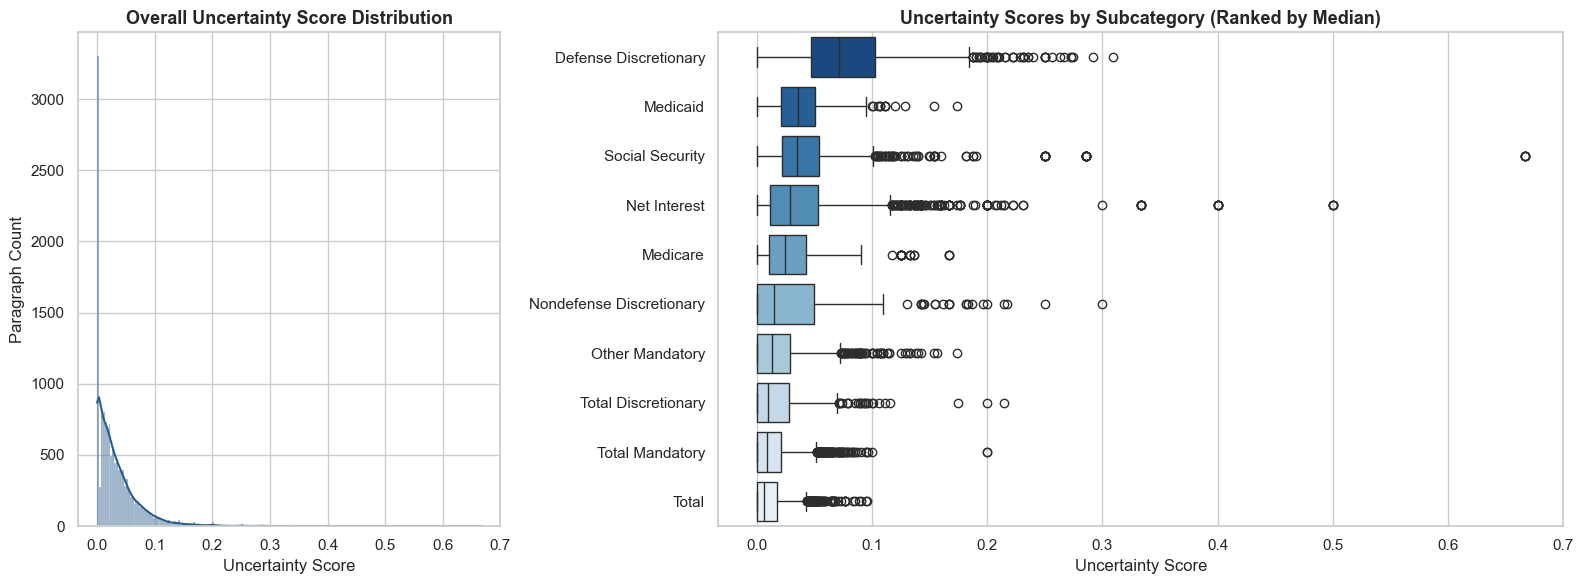

In [11]:
# Set a clean aesthetic for the plots
sns.set_theme(style="whitegrid")

# --- 1. Define your uncertainty column name ---
# Change 'uncertainty_score' if your column has a different name (e.g., 'uncert_score', 'score')
score_col = 'contextual_uncertainty_score' 


# --- 2. Print Descriptive Statistics ---
print("=== GLOBAL DESCRIPTIVE STATISTICS ===")
print(chunked_pg_w_embed_uncert[score_col].describe())
print("\n" + "="*40 + "\n")

print("=== DESCRIPTIVE STATISTICS BY SUBCATEGORY ===")
sub_stats = chunked_pg_w_embed_uncert.groupby('subcategory')[score_col].describe()
print(sub_stats)


# --- 3. Create Visualizations ---
# Set up a side-by-side subplot canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 2]})

# Left Plot: Global Distribution (Histogram + KDE)
sns.histplot(data=chunked_pg_w_embed_uncert, x=score_col, kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Overall Uncertainty Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Uncertainty Score')
axes[0].set_ylabel('Paragraph Count')

# Right Plot: Distribution by Subcategory (Boxplot)
# Sorting subcategories by median score to make the visualization easier to read
group_order = chunked_pg_w_embed_uncert.groupby('subcategory')[score_col].median().sort_values(ascending=False).index

sns.boxplot(
    data=chunked_pg_w_embed_uncert, 
    y='subcategory', 
    x=score_col, 
    ax=axes[1], 
    order=group_order,
    palette='Blues_r'
)
axes[1].set_title('Uncertainty Scores by Subcategory (Ranked by Median)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Uncertainty Score')
axes[1].set_ylabel('')  # Y-label is obvious from the categories

# Tighten layout and render
plt.tight_layout()
plt.show()

In [12]:
# export chunked_pg_w_embed with uncertainty score
chunked_pg_w_embed_uncert.to_csv("data_files/chunked_paragraphs_with_embeddings_uncert.csv", index=False)